In [56]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl
import scipy.stats as stats


os.chdir(r'c:\Repositories\asphalt-db')
#swithc working directory to 
from main.query_database import *
from main.data_classifications import *
from main.data_processing import *
from src.db_builder.models import *
sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')

## Import

In [57]:
#load the data
db_name = 'database_all_v5.sqlite'
dikes_and_projects = query_dikes_and_projects(sqlite3.connect(working_dir.parent.joinpath('data',db_name)))
df_final = load_and_merge_data(working_dir.parent.joinpath('data',db_name))
data_per_dike_project = get_section_based_statistics(df_final, dikes_and_projects)
df_final, data_per_dike_project = classifications_wrapper(df_final, data_per_dike_project)


#rename section schoor-wierum_ to t_schoor_-_wierum_46,1 - 49,7
# df_final.loc[df_final['dike_name']=='schoor-wierum_','dike_name'] = 't_schoor_-_wierum_46,1 - 49,7'
# #also in data_per_dike_project
# data_per_dike_project.loc[data_per_dike_project['dike_name']=='schoor-wierum_','dike_name'] = 't_schoor_-_wierum_46,1 - 49,7'

In [58]:
df_final.to_excel(working_dir.joinpath('database_all_v5.xlsx'), index=False)

In [59]:
# #manually add the sig_b for 'wierum-holwerd,vak2_42,9 - 46,1' from df_final
# wierum_holwerd_vak2_sig_b = [7.20, 7.60, 6.19, 7.21, 6.41]
# df_final.loc[df_final['dike_name'] == 'wierum-holwerd,vak2_42,9 - 46,1', 'sig_b'] = wierum_holwerd_vak2_sig_b

df_final['HR_category'] = df_final['HR'].apply(categorize_hr)
df_final.head()


,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,sig_perm,E_ini,E_50,N_fat,number_of_boreholes,HR_category,brittleness,material_class,construction_year_category,heterogeneity_category
0,1,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,0.118556,2366.0,2436.0,490.0,8,HR <4%,overgang,gemiddeld,1973-2000,Homogeen
1,2,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,0.114648,1826.0,2296.0,24000.0,8,HR <4%,overgang,gemiddeld,1973-2000,Homogeen
2,3,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,0.116814,2302.0,2157.0,2000.0,8,HR 4-9%,ductiel,gemiddeld,1973-2000,Homogeen
3,4,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,0.116208,1859.0,2615.0,29000.0,8,HR 4-9%,ductiel,gemiddeld,1973-2000,Homogeen
4,5,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,0.114500,2389.0,2209.0,2500.0,8,HR 4-9%,ductiel,gemiddeld,1973-2000,Homogeen


In [60]:
#make new df, grouped by project_id with mean and std for 'v', 'Sec_10', 'Sec_50', 'Sec_100', 'sig_b', 'eps_b', 'G_c', 'G_c_over_eps_b', 'G_c_over_eps_b_sig_b', 'V_Ber' 'pha_ini', 'pha_50', 'sig_cyc', 'sig_perm', 'E_ini', 'E_50', 'N_fat', 'HR_category```
data_per_dike_project = get_section_based_statistics(df_final, query_dikes_and_projects(sqlite3.connect(working_dir.parent.joinpath('data', 'database_all_v5.sqlite'))))

data_per_dike_project.head()



,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,V_Ber_cov,pha_ini_cov,pha_50_cov,sig_cyc_cov,sig_perm_cov,E_ini_cov,E_50_cov,N_fat_cov,HR_cov,bitumen_cov
0,1,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,0.183749,0.095103,0.132260,0.383971,0.023174,0.107258,0.066684,1.074097,0.243259,NaN
1,9,2,1959,2007,2,2,P_0702493,hellegatsdam_-,Rijkswaterstaat Zuid-Holland Waterdistrict Har...,48,...,0.659791,0.237534,0.247500,0.645213,0.020906,0.283323,0.263836,1.155408,0.511842,0.027918
2,25,3,1977,2009,3,3,P_0802158,"t_schoor_-_veerdam_holwerd_40,7 - 49,75",Wetterskip Fryslân,32,...,0.421361,2.828407,0.491943,0.432013,0.416429,2.821957,0.216079,1.916977,0.631492,0.048994
3,34,4,1977,2009,3,4,P_0802158,"zurichoord_6,55 - 7,4",Wetterskip Fryslân,32,...,0.183938,0.119420,0.213178,0.346888,0.331629,0.142695,0.101209,1.637312,0.327297,0.032286
4,18,5,1975,2009,3,5,P_0802158,"paesens_-_wierum_49,75 - 55,3",Wetterskip Fryslân,34,...,0.779845,0.261210,0.297501,0.353303,0.342894,0.085130,0.072947,1.839949,0.314560,0.069645


<Axes: xlabel='V_Ber', ylabel='sig_b'>

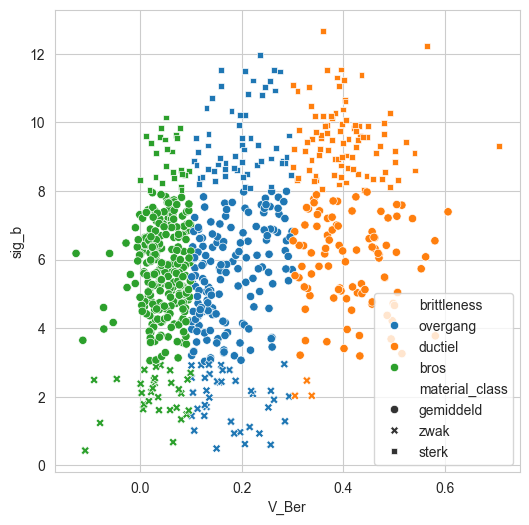

In [61]:
df_final['brittleness'] = df_final.apply(classify_brittleness, axis=1)
df_final['material_class'] = df_final.apply(classify_material_strength, axis=1)
df_final['construction_year_category'] = df_final.construction_year.apply(categorize_annum)
fig,ax = plt.subplots(figsize=(6, 6), ncols=1)
sns.scatterplot(data=df_final, x='V_Ber', y='sig_b', hue='brittleness',style='material_class', palette='tab10', ax=ax)


In [62]:
dike_names = df_final.dike_name.unique()
#get everything that contains 'schoor' or 'wierum' or 'holwerd'
schoor_wierum_dikes = [name for name in dike_names if 'schoor' in name.lower() or 'wierum' in name.lower() or 'holwerd' in name.lower()]

print(schoor_wierum_dikes)

#we only look at the part between 40,7 and 49,7 km. Exclude those that are outside this range ('paesens_-wierum_49,75 - 55,3', 'oostrand_groene_dijk_-_holwerd_37,9 - 40,7 '
dike_names = [name for name in schoor_wierum_dikes if name not in ['paesens_-_wierum_49,75 - 55,3', 'oostrand_groene_dijk_-_holwerd_37,9 - 40,7 ']]

['paesens_-_wierum_49,75 - 55,3', 't_schoor_-_veerdam_holwerd_40,7 - 49,75', 'wierum-holwerd,vak3_46,1 - 49,7', 'wierum-holwerd,vak2_42,9 - 46,1', 'wierum-holwerd,vak1_40,7 - 42,9', 'schoor-wierum_', 'oostrand_groene_dijk_-_holwerd_37,9 - 40,7 ', 't_schoor_-_wierum_46,1 - 49,7']


C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_25096\4056485147.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  schoor_wierum_data['dike_name'] = schoor_wierum_data['dike_name'].str.replace('schoor-wierum_', 't_schoor_-_wierum_46,1 - 49,7')
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_25096\4056485147.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  schoor_wierum_section_data['dike_name'] = schoor_wierum_section_data['dike_name'].str.replace('schoor-wierum_', 't_schoor_-_wierum_46,1 - 49,7')


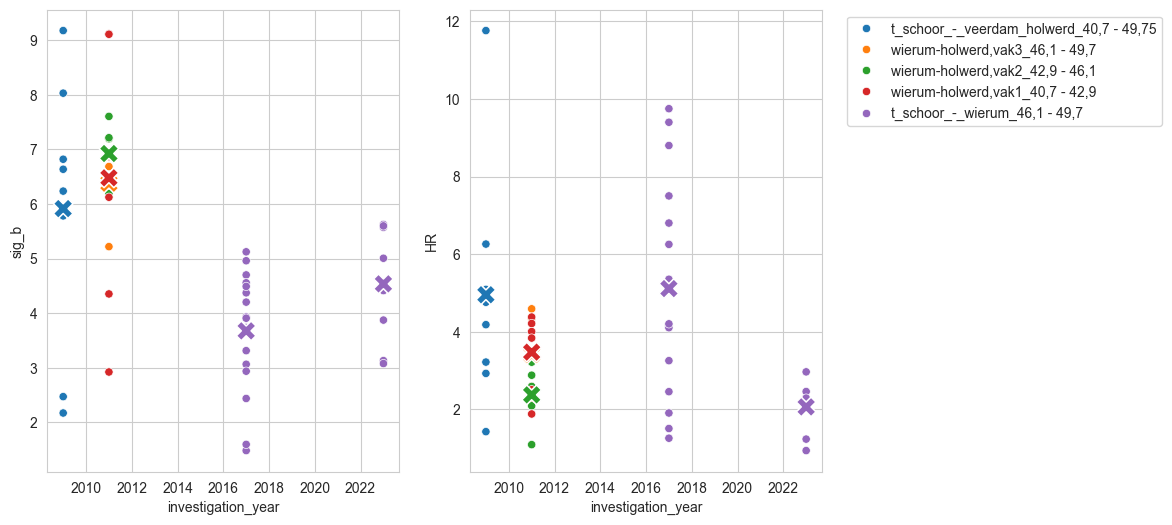

In [63]:
schoor_wierum_data = df_final[df_final['dike_name'].isin(dike_names)]\

#replace 'schoor-wierum_' with t_schoor_-_wierum_46,1 - 49,7
schoor_wierum_data['dike_name'] = schoor_wierum_data['dike_name'].str.replace('schoor-wierum_', 't_schoor_-_wierum_46,1 - 49,7')

schoor_wierum_section_data = data_per_dike_project[data_per_dike_project['dike_name'].isin(dike_names)]
schoor_wierum_section_data['dike_name'] = schoor_wierum_section_data['dike_name'].str.replace('schoor-wierum_', 't_schoor_-_wierum_46,1 - 49,7')


#make plots of schoor_wierum_data with age at investigation vs sig_b and investigation_year vs HR
#also include the means for each project_dike_id

fig, ax = plt.subplots(figsize=(10, 6), ncols = 2)
sns.scatterplot(ax=ax[0], data=schoor_wierum_data, x='investigation_year', y='sig_b', hue='dike_name', palette='tab10')
sns.scatterplot(ax=ax[0], data=schoor_wierum_section_data, x='investigation_year', y='sig_b_mean', hue='dike_name', palette='tab10', marker='X', s=200, legend=False)

sns.scatterplot(ax=ax[1], data=schoor_wierum_data, x='investigation_year', y='HR', hue='dike_name', palette='tab10')
sns.scatterplot(ax=ax[1], data=schoor_wierum_section_data, x='investigation_year', y='HR_mean', hue='dike_name', palette='tab10', marker='X', s=200, legend=False)
#remove legend for ax[0]
ax[0].legend_.remove()

ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

<Axes: xlabel='HR', ylabel='sig_b'>

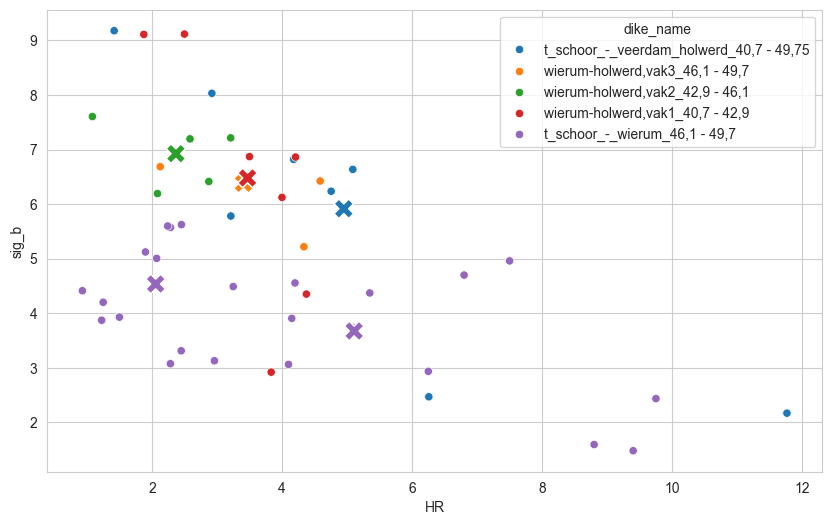

In [64]:
#make a similar plot but then for sig_b vs HR
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(ax=ax, data=schoor_wierum_data, x='HR', y='sig_b', hue='dike_name', palette='tab10')
sns.scatterplot(ax=ax, data=schoor_wierum_section_data, x='HR_mean', y='sig_b_mean', hue='dike_name', palette='tab10', marker='X', s=200, legend=False)

In [65]:
#for each project_dike_id compute the sig_b_5% value based on a student-t distribution with sig_b_mean, sig_b_std and number_of_boreholes
from scipy import stats
def compute_sig_b_5_percentile(row):
    mean = row['sig_b_mean']
    std = row['sig_b_std']
    n = row['number_of_boreholes_count']
    if n > 1:
        #degrees of freedom
        df = n - 1
        #t critical value for 5% percentile
        t_critical = stats.t.ppf(0.05, df)
        #5% percentile
        sig_b_5_percentile = mean + t_critical * std
        return sig_b_5_percentile
    else:
        return numpy.nan
schoor_wierum_section_data['sig_b_5_percentile'] = schoor_wierum_section_data.apply(compute_sig_b_5_percentile, axis=1)

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_25096\3148162183.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  schoor_wierum_section_data['sig_b_5_percentile'] = schoor_wierum_section_data.apply(compute_sig_b_5_percentile, axis=1)


In [66]:
#also merge vak1, vak2 and vak3 of wierum-holwerd into one section called wierum-holwerd_combined_40,7 - 49,7
wierum_holwerd_vak1 = schoor_wierum_data[schoor_wierum_data['dike_name'] == 'wierum-holwerd,vak1_40,7 - 42,9']
wierum_holwerd_vak2 = schoor_wierum_data[schoor_wierum_data['dike_name'] == 'wierum-holwerd,vak2_42,9 - 46,1']
wierum_holwerd_vak3 = schoor_wierum_data[schoor_wierum_data['dike_name'] == 'wierum-holwerd,vak3_46,1 - 49,7']
wierum_holwerd_combined = pd.concat([wierum_holwerd_vak1, wierum_holwerd_vak2, wierum_holwerd_vak3])
wierum_holwerd_combined['dike_name'] = 'wierum-holwerd_combined_40,7 - 49,7'


In [67]:
df

15

Text(0.5, 1.0, "Boorkernonderzoeken op het traject 't Schoor - Wierum - Holwerd")

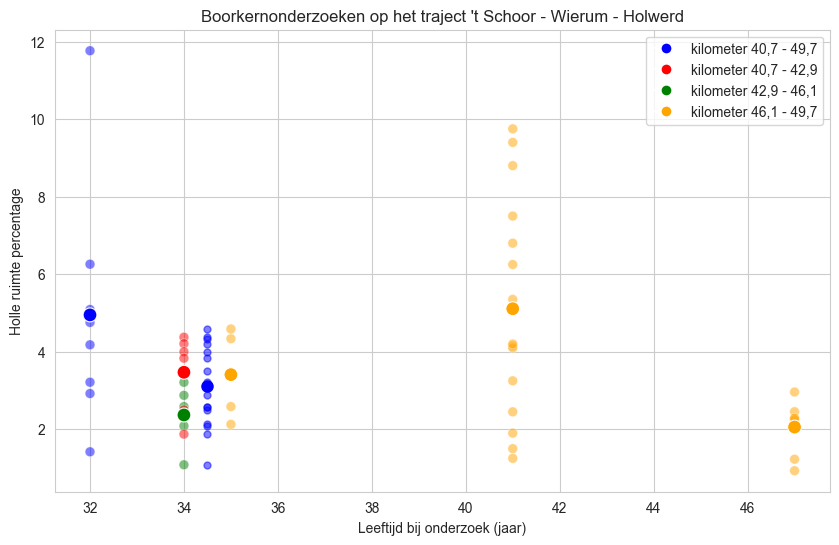

In [68]:
#plot the sig_b_5_percentile values
#make a hue_dictionary to assign a specific color to each dike_name
hue_dictionary = {
't_schoor_-_veerdam_holwerd_40,7 - 49,75': 'blue',
       'wierum-holwerd,vak3_46,1 - 49,7': 'orange',
       'wierum-holwerd,vak2_42,9 - 46,1': 'green',
       'wierum-holwerd,vak1_40,7 - 42,9': 'red', 
       't_schoor_-_wierum_46,1 - 49,7': 'orange',
       'schoor-wierum_': 'blue',

}
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(ax=ax, data=schoor_wierum_data, x='age_at_investigation', y='HR', hue='dike_name', palette=hue_dictionary, marker='o', s=50, legend=False,alpha=0.5)
sns.scatterplot(ax=ax, data=schoor_wierum_section_data, x='age_at_investigation', y='HR_mean', hue='dike_name', palette=hue_dictionary, marker='o', s=100, legend=False)
# sns.scatterplot(ax=ax, data=schoor_wierum_section_data, x='age_at_investigation', y='sig_b_5_percentile', hue='dike_name', palette=hue_dictionary, marker='X', s=200)
#plot wierum_holwerd_combined sig_b values as well
ax.plot([34.5]*len(wierum_holwerd_combined), wierum_holwerd_combined['HR'], color= 'blue', marker = 'o', linestyle = '', markersize=5, alpha = 0.5, label='wierum-holwerd_combined')
#plot mean and 5% value
ax.plot([34.5], [wierum_holwerd_combined['HR'].mean()], color = 'blue', marker = 'o', linestyle = '', markersize=8)
# #compute 5% percentile for wierum_holwerd_combined
# sig_b_mean = wierum_holwerd_combined['sig_b'].mean()
# sig_b_std = wierum_holwerd_combined['sig_b'].std()
# n = len(wierum_holwerd_combined)
# df = n - 1
# t_critical = stats.t.ppf(0.05, df)
# sig_b_5_percentile_wierum_holwerd_combined = sig_b_mean + t_critical * sig_b_std
# ax.plot([34.5], [sig_b_5_percentile_wierum_holwerd_combined], marker='X',color = 'blue',linestyle = '', markersize=12)\
ax.legend()
#legend labels: 
labels = ['kilometer 40,7 - 49,7', 'kilometer 40,7 - 42,9', 'kilometer 42,9 - 46,1', 'kilometer 46,1 - 49,7']
#create handles for blue dot, red dot, green dot, orange dot
handles = [plt.Line2D([0], [0], marker='o', color='w', label=labels[i], markerfacecolor=color, markersize=8) for i, color in enumerate(['blue', 'red', 'green', 'orange'])]
ax.legend(handles, labels)
ax.set_xlabel('Leeftijd bij onderzoek (jaar)')
ax.set_ylabel('Holle ruimte percentage')
ax.set_title("Boorkernonderzoeken op het traject 't Schoor - Wierum - Holwerd")

Text(0.5, 1.0, "Boorkernonderzoeken op het traject 't Schoor - Wierum - Holwerd")

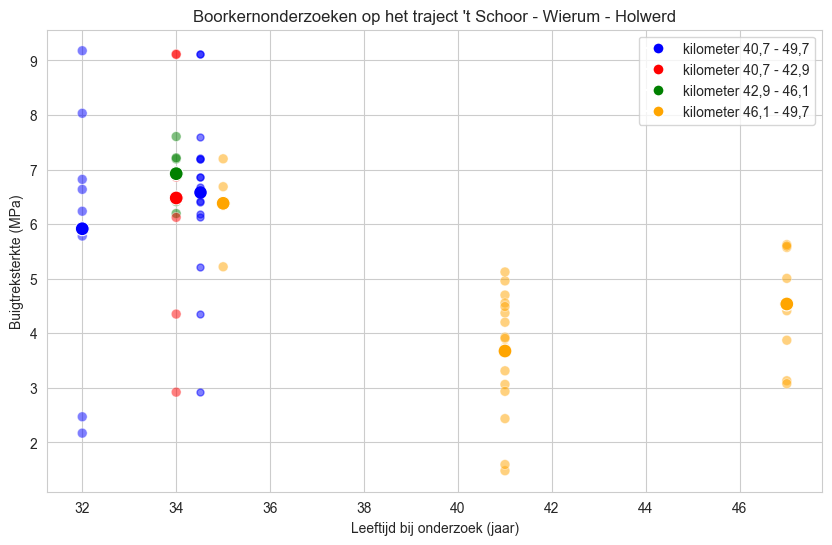

In [69]:
#plot the sig_b_5_percentile values
#make a hue_dictionary to assign a specific color to each dike_name
hue_dictionary = {
't_schoor_-_veerdam_holwerd_40,7 - 49,75': 'blue',
       'wierum-holwerd,vak3_46,1 - 49,7': 'orange',
       'wierum-holwerd,vak2_42,9 - 46,1': 'green',
       'wierum-holwerd,vak1_40,7 - 42,9': 'red', 
       't_schoor_-_wierum_46,1 - 49,7': 'orange',
       'schoor-wierum_': 'blue',

}
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(ax=ax, data=schoor_wierum_data, x='age_at_investigation', y='sig_b', hue='dike_name', palette=hue_dictionary, marker='o', s=50, legend=False,alpha=0.5)
sns.scatterplot(ax=ax, data=schoor_wierum_section_data, x='age_at_investigation', y='sig_b_mean', hue='dike_name', palette=hue_dictionary, marker='o', s=100, legend=False)
# sns.scatterplot(ax=ax, data=schoor_wierum_section_data, x='age_at_investigation', y='sig_b_5_percentile', hue='dike_name', palette=hue_dictionary, marker='X', s=200)
#plot wierum_holwerd_combined sig_b values as well
ax.plot([34.5]*len(wierum_holwerd_combined), wierum_holwerd_combined['sig_b'], color= 'blue', marker = 'o', linestyle = '', markersize=5, alpha = 0.5, label='wierum-holwerd_combined')
#plot mean and 5% value
ax.plot([34.5], [wierum_holwerd_combined['sig_b'].mean()], color = 'blue', marker = 'o', linestyle = '', markersize=8)
# #compute 5% percentile for wierum_holwerd_combined
# sig_b_mean = wierum_holwerd_combined['sig_b'].mean()
# sig_b_std = wierum_holwerd_combined['sig_b'].std()
# n = len(wierum_holwerd_combined)
# df = n - 1
# t_critical = stats.t.ppf(0.05, df)
# sig_b_5_percentile_wierum_holwerd_combined = sig_b_mean + t_critical * sig_b_std
# ax.plot([34.5], [sig_b_5_percentile_wierum_holwerd_combined], marker='X',color = 'blue',linestyle = '', markersize=12)\
ax.legend()
#legend labels: 
labels = ['kilometer 40,7 - 49,7', 'kilometer 40,7 - 42,9', 'kilometer 42,9 - 46,1', 'kilometer 46,1 - 49,7']
#create handles for blue dot, red dot, green dot, orange dot
handles = [plt.Line2D([0], [0], marker='o', color='w', label=labels[i], markerfacecolor=color, markersize=8) for i, color in enumerate(['blue', 'red', 'green', 'orange'])]
ax.legend(handles, labels)
ax.set_xlabel('Leeftijd bij onderzoek (jaar)')
ax.set_ylabel('Buigtreksterkte (MPa)')
ax.set_title("Boorkernonderzoeken op het traject 't Schoor - Wierum - Holwerd")

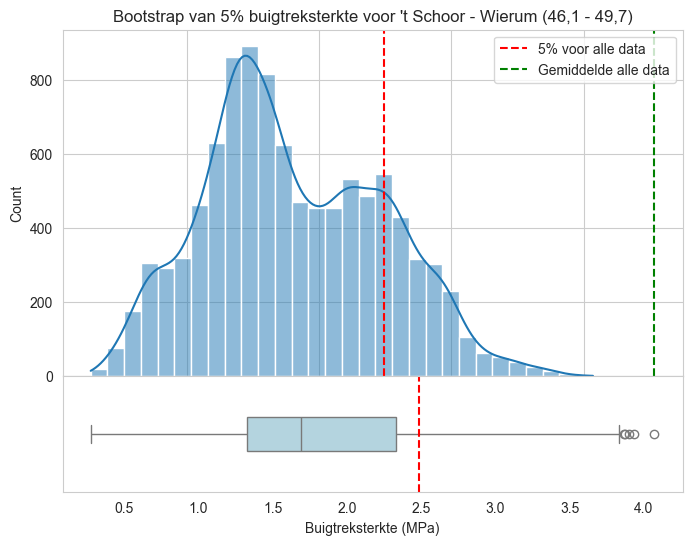

In [76]:
#for t_schoor_-_wierum_46,1 - 49,7 make a bootstrap analysis to compute the 5% percentile of sig_b for 1000 sets of 8 resamples
import random
bootstrap_samples = 10000
bootstrap_sig_b_5_percentiles = []
number_of_boreholes = 8
subset = schoor_wierum_data[schoor_wierum_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7']
for i in range(bootstrap_samples):
    resample = subset['sig_b'].sample(n=number_of_boreholes, replace=False)
    mean = resample.mean()
    std = resample.std()
    n = len(resample)
    df = n - 1
    t_critical = stats.t.ppf(0.05, df)
    sig_b_5_percentile = mean + t_critical * std
    bootstrap_sig_b_5_percentiles.append(sig_b_5_percentile)
#plot histogram of bootstrap_sig_b_5_percentiles
fig, ax = plt.subplots(figsize=(8, 6),nrows = 2, height_ratios=[3, 1])
sns.histplot(bootstrap_sig_b_5_percentiles, bins=30, kde=True, ax=ax[0])
#actual value from full set
ax[0].axvline(x=schoor_wierum_section_data.loc[schoor_wierum_section_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7', 'sig_b_5_percentile'].values[0], color='red', linestyle='--', label='5% voor alle data')
#add actual mean
ax[0].axvline(x=schoor_wierum_section_data.loc[schoor_wierum_section_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7', 'sig_b_mean'].values[0], color='green', linestyle='--', label='Gemiddelde alle data')
ax[0].legend()
# ax[0].set_xlabel('Buigtreksterkte (MPa)')
ax[0].set_title('Bootstrap van 5% buigtreksterkte voor \'t Schoor - Wierum (46,1 - 49,7)')
#remove xtick labels for ax[0]
ax[0].set_xticklabels([])

#add a boxplot to show the distribution of the bootstrap samples
sns.boxplot(x=bootstrap_sig_b_5_percentiles, ax=ax[1], color='lightblue',width = 0.3)
ax[1].axvline(x=schoor_wierum_section_data.loc[schoor_wierum_section_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7', 'sig_b_5_percentile'].values[0], color='red', linestyle='--', label='5% voor alle data')
ax[1].set_xlabel('Buigtreksterkte (MPa)')
# ax[1].set_title('Boxplot van bootstrap 5% buigtreksterkte voor t_schoor_-_wierum_46,1 - 49,7')
#do not show grid for boxplot
ax[1].grid(False)

#rescale figure canvas such that ax[0] has about 80% of total height
fig.subplots_adjust(hspace=0.0)




Text(0.5, 0.98, "Bootstrap analyse voor 't Schoor - Wierum (46,1 - 49,7)")

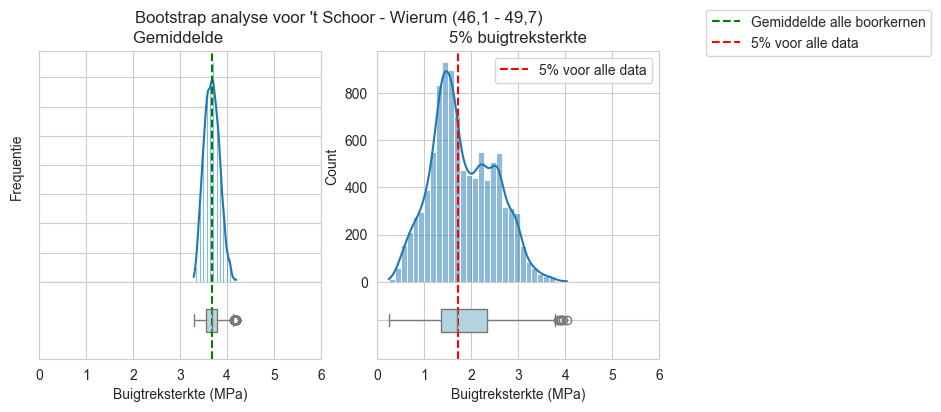

In [107]:
#we could also do a bootstrap for the mean sig_b values of t_schoor_-_wierum_46,1 - 49,7

bootstrap_samples = 10000
bootstrap_sig_b_means = []
subset = schoor_wierum_data[(schoor_wierum_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7') & (schoor_wierum_data.age_at_investigation == 41)]
overall_mean = subset['sig_b'].mean()
overall_std = subset['sig_b'].std()
overall_n = len(subset)
overall_df = overall_n - 1
t_critical = stats.t.ppf(0.05, overall_df)
overall_5_percentile = overall_mean + t_critical * overall_std

number_of_boreholes = 8

for i in range(bootstrap_samples):
    resample = subset['sig_b'].sample(n=number_of_boreholes, replace=False)
    mean = resample.mean()
    bootstrap_sig_b_means.append(mean)

#plot histogram of bootstrap_sig_b_means
fig, ax = plt.subplots(figsize=(8, 4),nrows = 2, ncols = 2, height_ratios=[3, 1])
sns.histplot(bootstrap_sig_b_means, bins=30, kde=True, ax=ax[0,0])
#actual mean value from full set
ax[0,0].axvline(x=overall_mean, color='green', linestyle='--', label='Gemiddelde alle boorkernen')
ax[0,0].legend()
# ax[0].set_xlabel('Buigtreksterkte (MPa)')
ax[0,0].set_title('Gemiddelde ')
#remove xtick labels for ax[0]
ax[0,0].set_xticklabels([])
#add a boxplot to show the distribution of the bootstrap samples
sns.boxplot(x=bootstrap_sig_b_means, ax=ax[1,0], color='lightblue',width = 0.3)
ax[1,0].axvline(x=overall_mean, color='green', linestyle='--', label='Gemiddelde alle boorkernen')
ax[1,0].set_xlabel('Buigtreksterkte (MPa)')
ax[0,0].set_xlim(0, 6)
ax[1,0].set_xlim(0, 6)
#get legend handles and labels
handles, labels = ax[1,0].get_legend_handles_labels()
#remove legend
ax[0,0].legend_.remove()
#for t_schoor_-_wierum_46,1 - 49,7 make a bootstrap analysis to compute the 5% percentile of sig_b for 1000 sets of 8 resamples
import random
bootstrap_samples = 10000
bootstrap_sig_b_5_percentiles = []
number_of_boreholes = 8
subset = schoor_wierum_data[schoor_wierum_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7']
for i in range(bootstrap_samples):
    resample = subset['sig_b'].sample(n=number_of_boreholes, replace=False)
    mean = resample.mean()
    std = resample.std()
    n = len(resample)
    df = n - 1
    t_critical = stats.t.ppf(0.05, df)
    sig_b_5_percentile = mean + t_critical * std
    bootstrap_sig_b_5_percentiles.append(sig_b_5_percentile)
#plot histogram of bootstrap_sig_b_5_percentiles
sns.histplot(bootstrap_sig_b_5_percentiles, bins=30, kde=True, ax=ax[0,1])
#actual value from full set
ax[0,1].axvline(x=overall_5_percentile, color='red', linestyle='--', label='5% voor alle data')
#add actual mean
# ax[0,1].axvline(x=overall_mean, color='green', linestyle='--', label='Gemiddelde alle data')
ax[0,1].legend()
# ax[0].set_xlabel('Buigtreksterkte (MPa)')
ax[0,1].set_title('5% buigtreksterkte')
#remove xtick labels for ax[0]
ax[0,1].set_xticklabels([])
ax[0,1].set_xlim(0, 6)

#add a boxplot to show the distribution of the bootstrap samples
sns.boxplot(x=bootstrap_sig_b_5_percentiles, ax=ax[1,1], color='lightblue',width = 0.3)
ax[1,1].axvline(x=overall_5_percentile, color='red', linestyle='--', label='5% voor alle data')
ax[1,1].set_xlabel('Buigtreksterkte (MPa)')
# ax[1].set_title('Boxplot van bootstrap 5% buigtreksterkte voor t_schoor_-_wierum_46,1 - 49,7')
#do not show grid for boxplot
ax[1,1].grid(True)
ax[1,1].set_xlim(0, 6)
ax[1,1].set_ylabel('')
ax[1,1].set_yticklabels([])
ax[0,0].set_yticklabels([])
ax[0,0].set_ylabel('Frequentie')
#get legend handles and labels
handles2, labels2 = ax[0,1].get_legend_handles_labels()
#make combined legend right of graph
#rescale figure canvas such that ax[0] has about 80% of total height
fig.subplots_adjust(hspace=0.0)
fig.legend(handles + handles2, labels + labels2, bbox_to_anchor=(.95, 1.0), loc='upper left')
fig.suptitle("Bootstrap analyse voor 't Schoor - Wierum (46,1 - 49,7)")





Text(0.5, 0, 'Buigtreksterkte (MPa)')

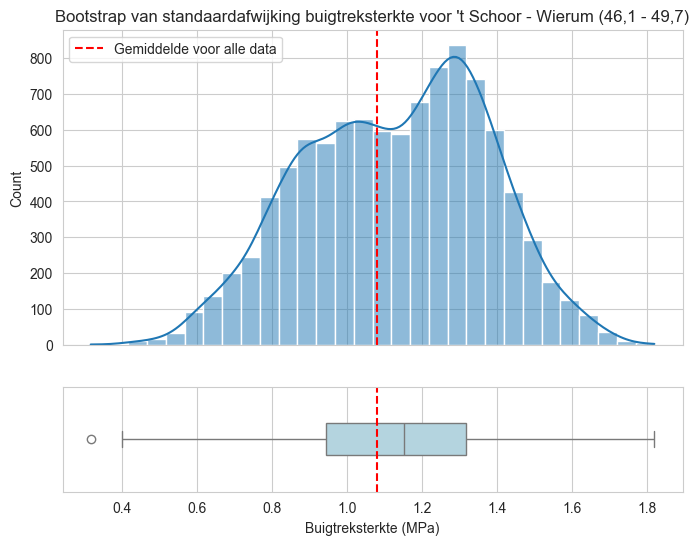

In [78]:
#we could also do a bootstrap for the std of sig_b values of t_schoor_-_wierum_46,1 - 49,7

bootstrap_samples = 10000
bootstrap_sig_b_stds = []
subset = schoor_wierum_data[schoor_wierum_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7']
for i in range(bootstrap_samples):
    resample = subset['sig_b'].sample(n=number_of_boreholes, replace=False)
    std = resample.std()
    bootstrap_sig_b_stds.append(std)

#plot histogram of bootstrap_sig_b_stds
fig, ax = plt.subplots(figsize=(8, 6),nrows = 2, height_ratios=[3, 1])
sns.histplot(bootstrap_sig_b_stds, bins=30, kde=True, ax=ax[0])
#actual mean value from full set
ax[0].axvline(x=schoor_wierum_section_data.loc[schoor_wierum_section_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7', 'sig_b_std'].values[0], color='red', linestyle='--', label='Gemiddelde voor alle data')
ax[0].legend()
# ax[0].set_xlabel('Buigtreksterkte (MPa)')
ax[0].set_title('Bootstrap van standaardafwijking buigtreksterkte voor \'t Schoor - Wierum (46,1 - 49,7)')
#remove xtick labels for ax[0]
ax[0].set_xticklabels([])
#add a boxplot to show the distribution of the bootstrap samples
sns.boxplot(x=bootstrap_sig_b_stds, ax=ax[1], color='lightblue',width = 0.3)
ax[1].axvline(x=schoor_wierum_section_data.loc[schoor_wierum_section_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7', 'sig_b_std'].values[0], color='red', linestyle='--', label='Gemiddelde voor alle data')
ax[1].set_xlabel('Buigtreksterkte (MPa)')


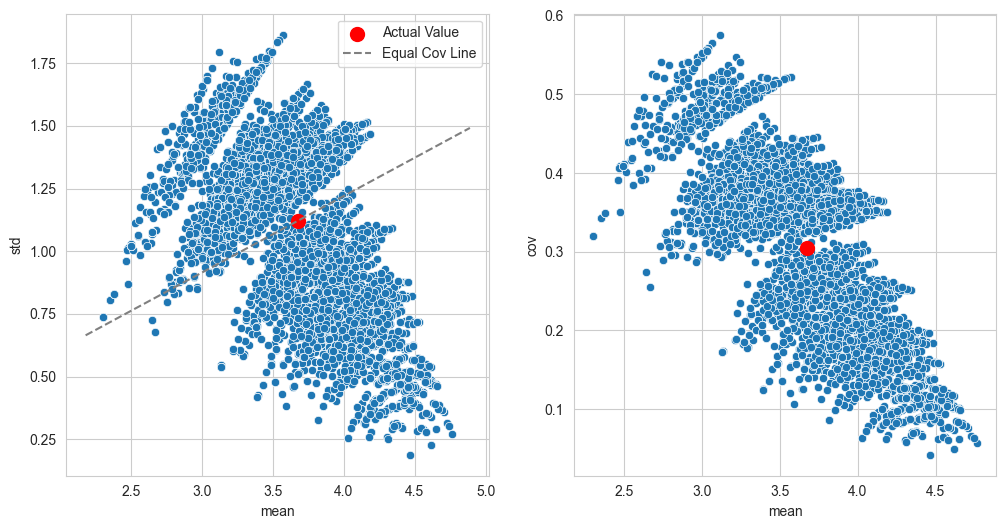

In [ ]:
# for 10000 bootstrap samples comupte mean, std and cov. Then plot scatterplots of mean vs std and mean vs cov
bootstrap_samples = 10000
bootstrap_sig_b_stats = []
subset = schoor_wierum_data[schoor_wierum_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7']
for i in range(bootstrap_samples):
    resample = subset['sig_b'].sample(n=number_of_boreholes, replace=False)
    mean = resample.mean()
    std = resample.std()
    cov = std / mean if mean != 0 else numpy.nan
    bootstrap_sig_b_stats.append((mean, std, cov))

#convert to dataframe
bootstrap_sig_b_stats_df = pd.DataFrame(bootstrap_sig_b_stats, columns=['mean', 'std', 'cov'])
#plot scatterplots
fig, ax = plt.subplots(figsize=(12, 6), ncols=2)
sns.scatterplot(data=bootstrap_sig_b_stats_df, x='mean', y='std', ax=ax[0])
sns.scatterplot(data=bootstrap_sig_b_stats_df, x='mean', y='cov', ax=ax[1])
#also include the actual values from schoor_wierum_section_data
actual_mean = schoor_wierum_section_data.loc[schoor_wierum_section_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7', 'sig_b_mean'].values[0]
actual_std = schoor_wierum_section_data.loc[schoor_wierum_section_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7', 'sig_b_std'].values[0]
actual_cov = schoor_wierum_section_data.loc[schoor_wierum_section_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7', 'sig_b_cov'].values[0]
ax[0].scatter(actual_mean, actual_std, color='red', s=100, label='Actual Value')
ax[1].scatter(actual_mean, actual_cov, color='red', s=100, label='Actual Value')
#plot line of equal cov in ax[0]
x_vals = numpy.array(ax[0].get_xlim())
y_vals = actual_cov * x_vals
ax[0].plot(x_vals, y_vals, '--', color='gray', label='Equal Cov Line')
ax[0].legend()

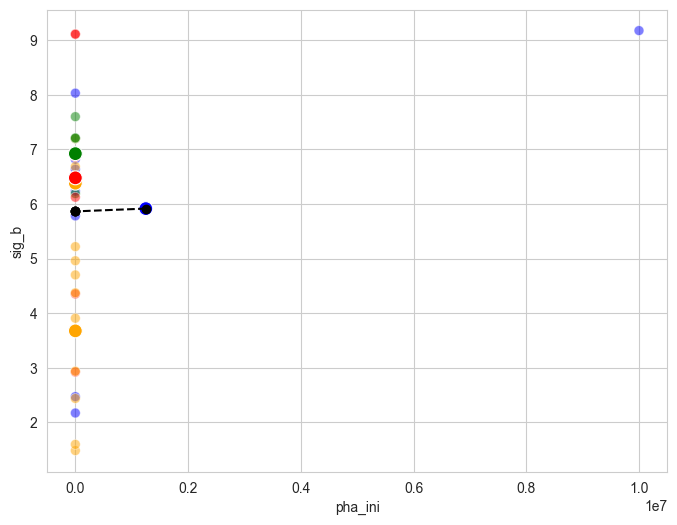

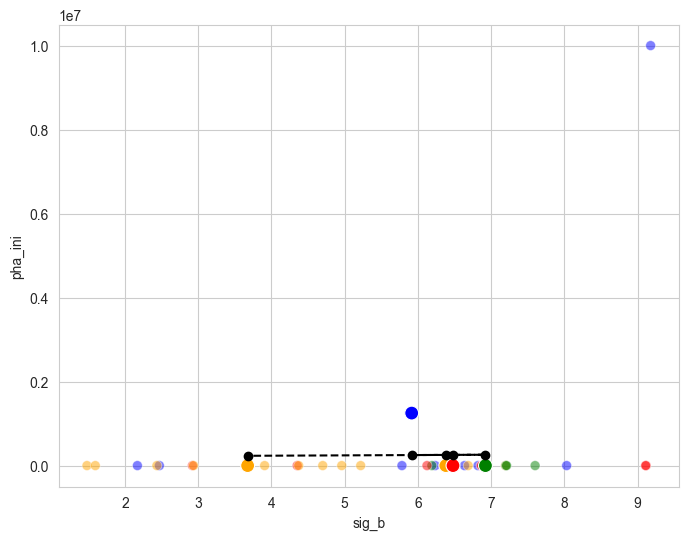

In [ ]:
import numpy as np
#plot pha_ini vs sig_b
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(ax=ax, data=schoor_wierum_data, x='pha_ini', y='sig_b', hue='dike_name', palette=hue_dictionary, marker='o', s=50, legend=False,alpha=0.5)
#mean values
sns.scatterplot(ax=ax, data=schoor_wierum_section_data, x='pha_ini_mean', y='sig_b_mean', hue='dike_name', palette=hue_dictionary, marker='o', s=100, legend=False)
#fit a linear regression line through the mean values
from sklearn.linear_model import LinearRegression


schoor_wierum_section_nonans = schoor_wierum_section_data.dropna(subset=['pha_ini_mean', 'sig_b_mean'])
X = schoor_wierum_section_nonans['pha_ini_mean'].values.reshape(-1, 1)
y = schoor_wierum_section_nonans['sig_b_mean'].values.reshape(-1, 1)
#drop nan values

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
ax.plot(schoor_wierum_section_nonans['pha_ini_mean'], y_pred, color='black', linestyle='--',marker = 'o', label='Linear regression')

#swap x and y
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(ax=ax, data=schoor_wierum_data, x='sig_b', y='pha_ini', hue='dike_name', palette=hue_dictionary, marker='o', s=50, legend=False,alpha=0.5)
#mean values
sns.scatterplot(ax=ax, data=schoor_wierum_section_data, x='sig_b_mean', y='pha_ini_mean', hue='dike_name', palette=hue_dictionary, marker='o', s=100, legend=False)
#fit a linear regression line through the mean values

model = LinearRegression().fit(y, X)
y_pred = model.predict(y)
ax.plot(schoor_wierum_section_nonans['sig_b_mean'], y_pred, color='black', linestyle='--',marker = 'o', label='Linear regression')


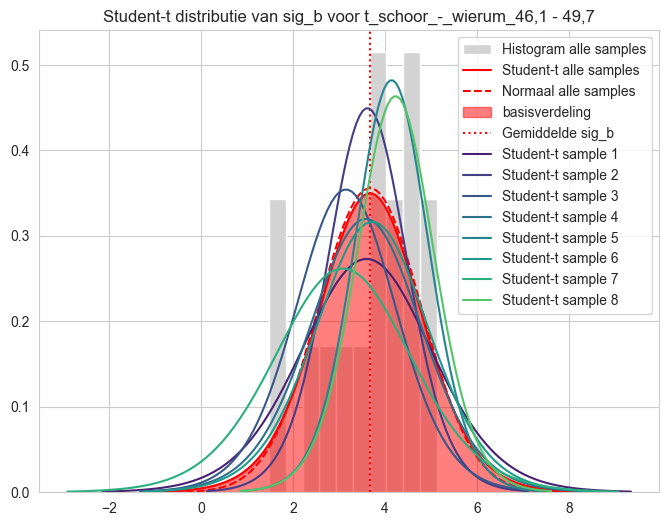

In [ ]:
#we look at t_schoor_-_wierum_46,1 - 49,7
subset = schoor_wierum_data[schoor_wierum_data['dike_name'] == 't_schoor_-_wierum_46,1 - 49,7']
palette = sns.color_palette('viridis', n_colors=10)
#based on the computed mean and std, and the degree of freedom, we can plot a student-t distribution to show the uncertainty in the sig_b values
mean = subset['sig_b'].mean()
std = subset['sig_b'].std()
n = len(subset)
df = n - 1
x = np.linspace(mean - 4*std, mean + 4*std, 100)
y = stats.t.pdf(x, df, loc=mean, scale=std)
y_normal = stats.norm.pdf(x, loc=mean, scale=std)
fig, ax = plt.subplots(figsize=(8, 6))
subset.hist(column='sig_b', bins=10, density=True, color='lightgray', label='Histogram alle samples', ax=ax)
ax.plot(x, y, label='Student-t alle samples', color='red')
ax.plot(x, y_normal, label='Normaal alle samples', linestyle='--',color = 'red')
ax.fill_between(x, y, color='red', alpha=0.5, label='basisverdeling')
ax.axvline(x=mean, color='red', linestyle=':', label='Gemiddelde sig_b')
ax.set_title('Student-t distributie van sig_b voor t_schoor_-_wierum_46,1 - 49,7')

#now we are randomly sampling 8 values from the subset and plot the corresponding student-t distribution we do this 8 times in a loop
for i in range(8):
    random_samples = subset['sig_b'].sample(n=number_of_boreholes, replace=False)
    mean = random_samples.mean()
    std = random_samples.std()
    x = np.linspace(mean - 4*std, mean + 4*std, 100)
    y = stats.t.pdf(x, df, loc=mean, scale=std)
    ax.plot(x, y, label=f'Student-t sample {i+1}', color=palette[i])
ax.legend()

